<a href="https://colab.research.google.com/github/rodrigourech/gdv/blob/main/notebooks/LO1%20%E2%80%93%20Foundations%20of%20Visualization%20and%20Chart%20Types.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LO1 – Foundations of Visualization and Chart Types**

In [52]:
# --- Colab setup: imports & figure style ---
import io
import math
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.facecolor"] = "white"

RAW_BASE = "https://raw.githubusercontent.com/rodrigourech/gdv/main/"
FILES = {
    "tas_RCP45": RAW_BASE + "RCP45_tas.csv",
    "tas_RCP85": RAW_BASE + "RCP85_tas.csv",
    "pr_RCP45":  RAW_BASE + "RCP45_pr.csv",
    "pr_RCP85":  RAW_BASE + "RCP85_pr.csv",
}

PREFERRED_STATION = "Zürich"
BASELINE_YEARS = (1991, 2020)
FUTURE_YEARS = (2070, 2099)


In [53]:
tas45 = load_climate_csv(FILES["tas_RCP45"], var_hint="tas")
tas85 = load_climate_csv(FILES["tas_RCP85"], var_hint="tas")
pr45  = load_climate_csv(FILES["pr_RCP45"],  var_hint="pr")
pr85  = load_climate_csv(FILES["pr_RCP85"],  var_hint="pr")

tas = pd.concat([tas45, tas85], ignore_index=True)
pr  = pd.concat([pr45, pr85], ignore_index=True)

# pick station (use preferred if available, else first)
all_stations = (
    tas["station"].dropna().unique().tolist() +
    pr["station"].dropna().unique().tolist()
)
all_stations = [s for s in all_stations if isinstance(s, str)]
chosen_station = next((s for s in all_stations if PREFERRED_STATION.lower() in s.lower()),
                      (all_stations[0] if all_stations else "Unknown"))

print("Stations found (sample):", sorted(list(set(all_stations)))[:10], "...")
print("Using station:", chosen_station)

tas_s = tas[tas["station"] == chosen_station].dropna(subset=["value"]).sort_values("date")
pr_s  = pr[pr["station"] == chosen_station].dropna(subset=["value"]).sort_values("date")

assert len(tas_s) > 0, "No temperature data for the chosen station."
assert len(pr_s)  > 0, "No precipitation data for the chosen station."


Stations found (sample): ['Basel', 'Bern', 'Davos', 'Lugano', 'Payerne', 'Sion', 'St. Gallen', 'Zürich'] ...
Using station: Zürich


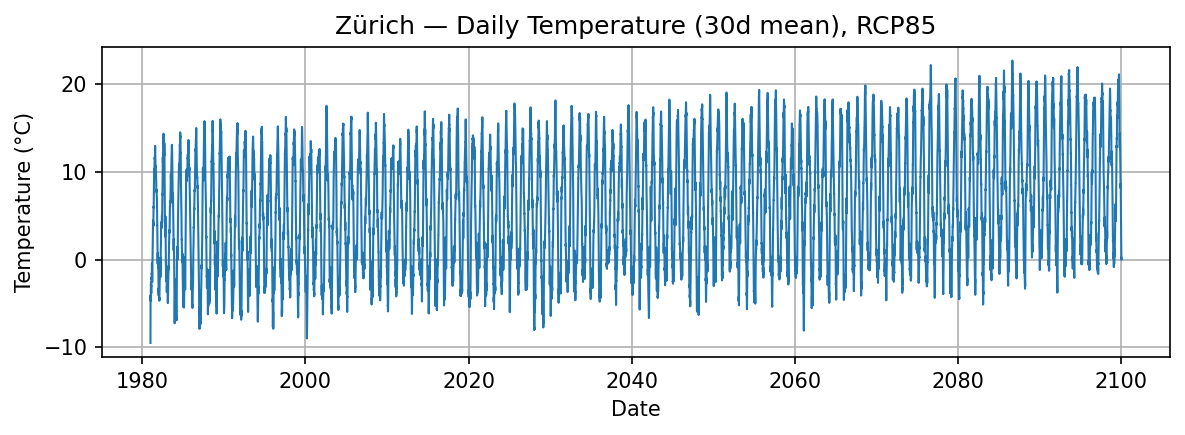

In [54]:
fig, ax = plt.subplots(figsize=(8,3))

scen = "RCP85"
d = tas_s[tas_s["scenario"] == scen].copy()
d["tas_roll30"] = d["value"].rolling(30, min_periods=1).mean()

ax.plot(d["date"], d["tas_roll30"], linewidth=1)
ax.set_title(f"{chosen_station} — Daily Temperature (30d mean), {scen}")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
fig.tight_layout()
plt.show()


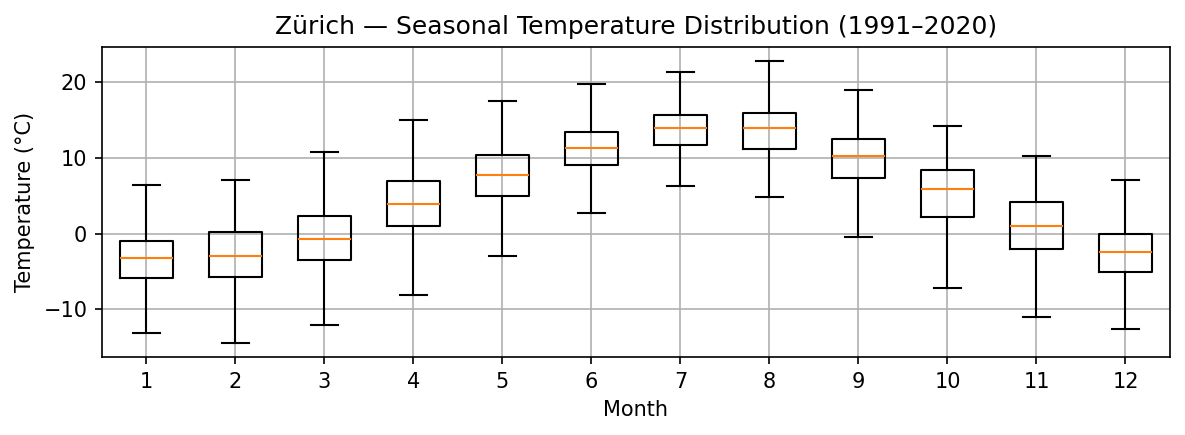

In [55]:
y0, y1 = BASELINE_YEARS
base = tas_s[(tas_s["year"]>=y0) & (tas_s["year"]<=y1)]

data_by_month = [base[base["month"]==m]["value"].dropna().values for m in range(1,13)]

fig, ax = plt.subplots(figsize=(8,3))
bp = ax.boxplot(data_by_month, positions=range(1,13), widths=0.6, showfliers=False)
ax.set_title(f"{chosen_station} — Seasonal Temperature Distribution ({y0}–{y1})")
ax.set_xlabel("Month")
ax.set_ylabel("Temperature (°C)")
ax.set_xticks(range(1,13))
fig.tight_layout()
plt.show()


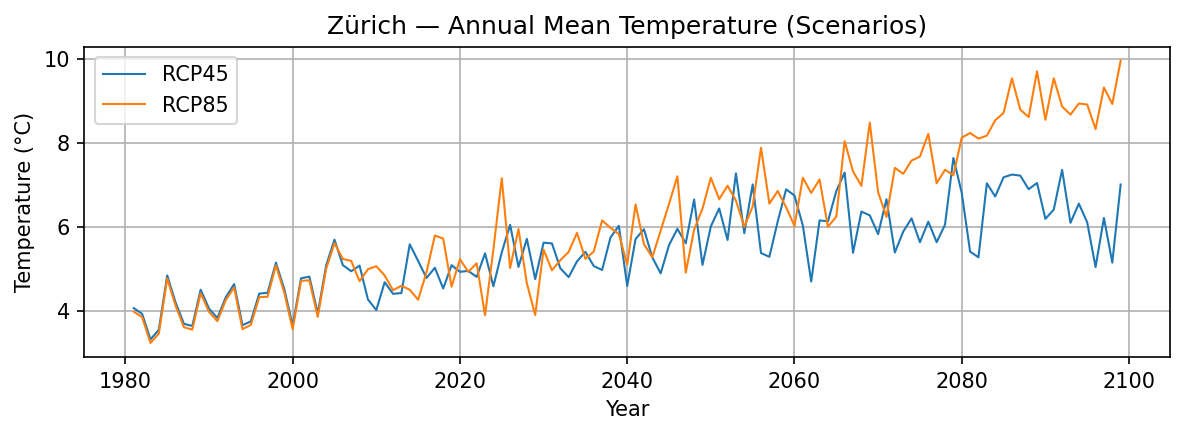

In [56]:
ann = (
    tas_s.groupby(["scenario","year"], as_index=False)["value"]
    .mean()
    .rename(columns={"value":"tas_ann_mean"})
)

fig, ax = plt.subplots(figsize=(8,3))
for scen in ["RCP45","RCP85"]:
    d = ann[ann["scenario"]==scen]
    ax.plot(d["year"], d["tas_ann_mean"], label=scen, linewidth=1)

ax.legend()
ax.set_title(f"{chosen_station} — Annual Mean Temperature (Scenarios)")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
fig.tight_layout()
plt.show()


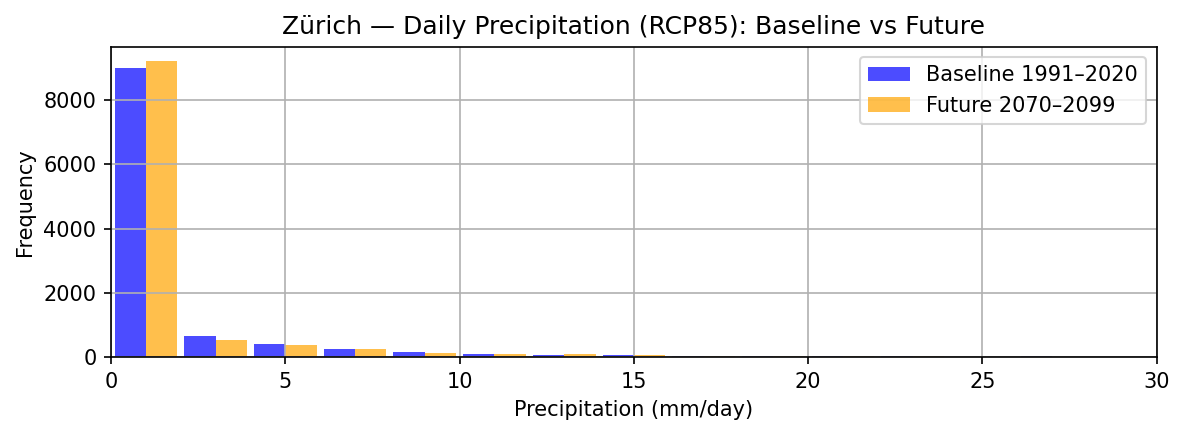

In [59]:
y0, y1 = BASELINE_YEARS
f0, f1 = FUTURE_YEARS

pr85_s = pr_s[pr_s["scenario"]=="RCP85"].copy()
base = pr85_s[(pr85_s["year"]>=y0) & (pr85_s["year"]<=y1)]["value"].clip(upper=60)
fut  = pr85_s[(pr85_s["year"]>=f0) & (pr85_s["year"]<=f1)]["value"].clip(upper=60)

bins = np.arange(0, 61, 2)

base_counts, _ = np.histogram(base, bins=bins)
fut_counts, _  = np.histogram(fut,  bins=bins)

# Bar width & offsets
width = 0.9 * (bins[1] - bins[0]) / 2  # ~half the bin width
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- Plot side-by-side bars ---
fig, ax = plt.subplots(figsize=(8, 3))

ax.bar(bin_centers - width/2, base_counts, width=width, color='blue', alpha=0.7,
       label=f"Baseline {y0}–{y1}")
ax.bar(bin_centers + width/2, fut_counts,  width=width, color='orange', alpha=0.7,
       label=f"Future {f0}–{f1}")

ax.set_title(f"{chosen_station} — Daily Precipitation (RCP85): Baseline vs Future")
ax.set_xlabel("Precipitation (mm/day)")
ax.set_ylabel("Frequency")
ax.set_xlim(0, 30)
ax.legend()
fig.tight_layout()
plt.show()
